# Task 2.1 Analysis of Symptom Co-occurrence Patterns

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
import os
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: ./outputs


In [ ]:
# Check if file exists
filepath = 'data/disease_symptom/dataset.csv'
print(f"File exists: {os.path.exists(filepath)}")

df = pd.read_csv(filepath)
print("Shape of data",df.shape)

File exists: True
Shape of data (4920, 18)


In [ ]:
def get_comprehensive_synonym_map():
    return {
        # respiratory
        "dry cough": "cough",
        "continuous cough": "cough",
        "persistent cough": "cough",
        "breathlessness": "shortness of breath",
        "difficulty breathing": "shortness of breath",

        # fever-related
        "high fever": "fever",
        "mild fever": "fever",
        "pyrexia": "fever",

        # pain-related
        "severe headache": "headache",
        "mild headache": "headache",
        "stomach pain": "abdominal pain",
        "tummy pain": "abdominal pain",
        "chest tightness": "chest pain",

        # fatigue  
        "tiredness": "fatigue",
        "exhaustion": "fatigue",
        "weakness": "fatigue",

        # nausea now mapped to fatigue
        "nausea": "fatigue",
        "queasiness": "fatigue",

        # vomiting
        "throwing up": "vomiting",

        # diarrhea
        "loose stools": "diarrhea",
        "watery stool": "diarrhea",

        # cold/flu-like
        "rhinorrhea": "runny nose",
        "throat pain": "sore throat",

        # skin-related
        "itching": "skin rash",
        "itchy skin": "skin rash",
        "redness": "skin rash",
        "red patches": "skin rash",
        "hives": "skin rash",
        "urticaria": "skin rash",
        "blisters": "skin rash",
        "skin irritation": "skin rash",
        "maculopapular rash": "skin rash",

        # swelling
        "inflammation": "swelling",

        # appetite
        "poor appetite": "loss of appetite",

        # dizziness
        "lightheaded": "dizziness",

        # joint/body pain
        "arthralgia": "joint pain",
        "muscle pain": "body ache",
        "myalgia": "body ache",
    }

In [ ]:
# APRIORI ALGORITHM IMPLEMENTATION
# Agrawal, R., & Srikant, R. (1994). "Fast algorithms for mining association rules"
class AprioriAlgorithm:
    def __init__(self, min_support=0.1, min_confidence=0.5):
        """
        Initialize Apriori algorithm with parameters.
        
        Args:
            min_support (float): Minimum support threshold (0-1)
            min_confidence (float): Minimum confidence for association rules (0-1)
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.frequent_itemsets = {}
        self.association_rules = []
        
    def get_unique_items(self, transactions):
        unique_items = set()
        for transaction in transactions:
            for item in transaction:
                unique_items.add(frozenset([item]))
        return unique_items
    
    def calculate_support(self, itemset, transactions):
        count = 0
        for transaction in transactions:
            if itemset.issubset(transaction):
                count += 1
        support_ratio = count / len(transactions)
        return count, support_ratio
    
    def generate_candidates(self, prev_frequent_itemsets, k):
        candidates = set()
        n = len(prev_frequent_itemsets)
        
        # Join step: combine itemsets with k-2 common items
        for i in range(n):
            for j in range(i + 1, n):
                # Union of two k-1 itemsets
                candidate = prev_frequent_itemsets[i] | prev_frequent_itemsets[j]
                
                # Check if size is k (should have exactly k items)
                if len(candidate) == k:
                    candidates.add(candidate)
        
        return candidates
    
    def prune_candidates(self, candidates, prev_frequent_itemsets, k):
        pruned_candidates = set()
        
        for candidate in candidates:
            # Get all k-1 subsets
            subsets = [frozenset(s) for s in combinations(candidate, k - 1)]
            
            # Check if all subsets are frequent
            all_frequent = all(subset in prev_frequent_itemsets for subset in subsets)
            
            if all_frequent:
                pruned_candidates.add(candidate)
        
        return pruned_candidates
    
    def fit(self, transactions, verbose=True):
        # Convert transactions to list of sets
        transactions = [set(t) for t in transactions]
        n_transactions = len(transactions)
        
        if verbose:
            print(f"Running Apriori Algorithm")
            print(f"Total transactions: {n_transactions}")
            print(f"Minimum support: {self.min_support} ({int(self.min_support * n_transactions)} transactions)")
            print("=" * 60)
        
        # Initialize with 1-itemsets
        k = 1
        candidates = self.get_unique_items(transactions)
        frequent_itemsets_dict = {}
        
        while candidates:
            if verbose:
                print(f"\nIteration k={k}:")
                print(f"  Candidates: {len(candidates)}")
            
            # Calculate support for all candidates
            frequent_k_itemsets = []
            itemset_support = {}
            
            for itemset in candidates:
                count, support = self.calculate_support(itemset, transactions)
                
                if support >= self.min_support:
                    frequent_k_itemsets.append(itemset)
                    itemset_support[itemset] = {'count': count, 'support': support}
            
            if not frequent_k_itemsets:
                break
            
            frequent_itemsets_dict[k] = itemset_support
            
            if verbose:
                print(f"  Frequent itemsets: {len(frequent_k_itemsets)}")
            
            # Generate candidates for next iteration
            k += 1
            if k == 2:
                # For k=2, just combine all 1-itemsets
                candidates = set()
                items = list(frequent_k_itemsets)
                for i in range(len(items)):
                    for j in range(i + 1, len(items)):
                        candidates.add(items[i] | items[j])
            else:
                # For k>2, use the generate and prune method
                candidates = self.generate_candidates(frequent_k_itemsets, k)
                if k > 2:
                    prev_frequent_set = set(frequent_k_itemsets)
                    candidates = self.prune_candidates(candidates, prev_frequent_set, k)
        
        self.frequent_itemsets = frequent_itemsets_dict
        
        if verbose:
            print("\n" + "=" * 60)
            print("Apriori Algorithm Completed!")
            total_frequent = sum(len(itemsets) for itemsets in frequent_itemsets_dict.values())
            print(f"Total frequent itemsets found: {total_frequent}")
        
        return frequent_itemsets_dict
    
    def generate_association_rules(self, min_confidence=None, verbose=True):  
        if min_confidence is None:
            min_confidence = self.min_confidence
        
        rules = []
        
        # Only generate rules from itemsets of size >= 2
        for k in range(2, max(self.frequent_itemsets.keys()) + 1):
            if k not in self.frequent_itemsets:
                continue
            
            for itemset, metrics in self.frequent_itemsets[k].items():
                items = list(itemset)
                
                # Generate all possible rules from this itemset
                for i in range(1, len(items)):
                    # Generate all antecedents of size i
                    for antecedent_tuple in combinations(items, i):
                        antecedent = frozenset(antecedent_tuple)
                        consequent = itemset - antecedent
                        
                        # Calculate confidence
                        # Confidence(A->B) = Support(A∪B) / Support(A)
                        antecedent_size = len(antecedent)
                        if antecedent_size in self.frequent_itemsets:
                            if antecedent in self.frequent_itemsets[antecedent_size]:
                                antecedent_support = self.frequent_itemsets[antecedent_size][antecedent]['support']
                                confidence = metrics['support'] / antecedent_support
                                
                                if confidence >= min_confidence:
                                    # Calculate lift
                                    consequent_size = len(consequent)
                                    if consequent_size in self.frequent_itemsets:
                                        if consequent in self.frequent_itemsets[consequent_size]:
                                            consequent_support = self.frequent_itemsets[consequent_size][consequent]['support']
                                            lift = confidence / consequent_support
                                        else:
                                            lift = None
                                    else:
                                        lift = None
                                    
                                    rules.append({
                                        'antecedent': antecedent,
                                        'consequent': consequent,
                                        'support': metrics['support'],
                                        'confidence': confidence,
                                        'lift': lift
                                    })
        
        self.association_rules = sorted(rules, key=lambda x: x['confidence'], reverse=True)
        
        if verbose:
            print(f"\nGenerated {len(self.association_rules)} association rules")
            print(f"Minimum confidence threshold: {min_confidence}")
        
        return self.association_rules


In [ ]:
def load_disease_symptom_data(filepath):
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset loaded successfully!")
        print(f"Shape: {df.shape}")
        print(f"\nColumns: {df.columns.tolist()}")
        return df
    except FileNotFoundError:
        print(f"Error: File '{filepath}' not found.")
        print("Please place the dataset CSV in the same directory as this script.")
        print("Or update the filepath in the main() function.")
        return None

In [ ]:
def clean_symptoms(symptom):
    if pd.isna(symptom) or symptom == '' or symptom.strip() == '':
        return None
    
    # Convert to lowercase and strip whitespace
    symptom = str(symptom).lower().strip()
    
    # Remove special characters but keep underscores and hyphens
    symptom = symptom.replace('_', ' ')
    
    return symptom

In [ ]:
def prepare_transactions(df, normalize_synonyms=True, verbose=True):
    if verbose:
        print("="*60)
        print("DATA PREPARATION")
        print("="*60)
        print(f"Input dataframe shape: {df.shape}")
    
    # Get symptom columns
    symptom_cols = [col for col in df.columns if 'Symptom' in col]
    if verbose:
        print(f"Symptom columns found: {len(symptom_cols)}")
    
    # Transform wide format to long format
    df_long = df.melt(
        id_vars=['Disease'], 
        value_vars=symptom_cols,
        value_name='Symptom'
    )
    
    if verbose:
        print(f"After melting: {df_long.shape}")
    
    # Data Cleaning
    df_long['Symptom'] = df_long['Symptom'].str.lower().str.strip()
    df_long = df_long.dropna(subset=['Symptom'])
    df_long['Symptom'] = df_long['Symptom'].str.replace('_', ' ')
    
    if verbose:
        print(f"After cleaning: {df_long.shape}")
        print(f"Unique symptoms before normalization: {df_long['Symptom'].nunique()}")
    
    # Apply synonym normalization
    if normalize_synonyms:
        synonym_map = get_comprehensive_synonym_map()
        df_long['Symptom'] = df_long['Symptom'].map(lambda x: synonym_map.get(x, x))
        
        if verbose:
            print(f"Unique symptoms after normalization: {df_long['Symptom'].nunique()}")
    
    # Group by disease to create transactions
    # Each UNIQUE disease becomes ONE transaction
    transactions = []
    disease_names = []
    
    for disease, group in df_long.groupby('Disease'):
        symptoms = set(group['Symptom'].unique())
        if symptoms:
            transactions.append(symptoms)
            disease_names.append(disease)
    
    # Calculate symptom statistics
    symptom_counts = df_long['Symptom'].value_counts()
    symptom_stats = symptom_counts.to_dict()
    
    if verbose:
        print("\n" + "="*60)
        print("TRANSACTION SUMMARY")
        print("="*60)
        print(f"Total Unique Disease Profiles (Transactions): {len(transactions)}")
        print(f"Unique diseases: {len(set(disease_names))}")
        print(f"Unique symptoms: {len(symptom_stats)}")
        
        symptoms_per_transaction = [len(t) for t in transactions]
        print(f"\nSymptoms per transaction:")
        print(f"  Min: {min(symptoms_per_transaction)}")
        print(f"  Max: {max(symptoms_per_transaction)}")
        print(f"  Mean: {np.mean(symptoms_per_transaction):.2f}")
        
        print(f"\nTop 10 most frequent symptoms:")
        for i, (symptom, count) in enumerate(symptom_counts.head(10).items(), 1):
            pct = (count / len(transactions)) * 100
            print(f"  {i:2d}. {symptom:30s}: {count:3d} ({pct:5.1f}%)")
    
    return transactions, disease_names, symptom_stats

In [32]:
def augment_transactions(transactions, disease_names, noise_rate=0.05, verbose=True):
    if verbose:
        print("\n" + "="*60)
        print("DATA AUGMENTATION")
        print("="*60)
        print(f"Original transactions: {len(transactions)}")
        print(f"Noise rate: {noise_rate*100:.1f}%")
    
    augmented_transactions = transactions.copy()
    augmented_names = disease_names.copy()
    
    # Create noisy mirrors
    mirror_count = 0
    symptoms_removed = []
    
    for i, transaction in enumerate(transactions):
        noisy_transaction = transaction.copy()
        original_size = len(noisy_transaction)
        
        # Randomly remove symptoms based on noise_rate
        symptoms_to_remove = [s for s in noisy_transaction 
                             if np.random.rand() < noise_rate]
        
        for symptom in symptoms_to_remove:
            noisy_transaction.discard(symptom)
        
        removed = original_size - len(noisy_transaction)
        symptoms_removed.append(removed)
        
        # Only add if we still have symptoms
        if noisy_transaction:
            augmented_transactions.append(noisy_transaction)
            augmented_names.append(disease_names[i] + '_NOISY_MIRROR')
            mirror_count += 1
    
    if verbose:
        print(f"Noisy mirrors created: {mirror_count}")
        print(f"Augmented transactions: {len(augmented_transactions)}")
        print(f"Increase: +{len(augmented_transactions) - len(transactions)}")
        
        if symptoms_removed:
            print(f"\nSymptoms removed per mirror:")
            print(f"  Mean: {np.mean(symptoms_removed):.2f}")
            print(f"  Max: {max(symptoms_removed)}")
    
    return augmented_transactions, augmented_names

In [ ]:
def inspect_melted_dataframe(df):
    """
    Print and inspect the melted dataframe structure
    """
    # Get symptom columns
    symptom_cols = [col for col in df.columns if 'Symptom' in col]
    
    # Melt the dataframe
    df_long = df.melt(
        id_vars=['Disease'], 
        value_vars=symptom_cols,
        value_name='Symptom'
    )
    
    print("="*70)
    print("MELTED DATAFRAME INSPECTION")
    print("="*70)
    
    print(f"\nOriginal shape: {df.shape}")
    print(f"Melted shape: {df_long.shape}")
    
    print(f"\nColumns in melted dataframe:")
    print(df_long.columns.tolist())
    
    print(f"\nFirst 20 rows of melted dataframe:")
    print(df_long.head(20))
    
    print(f"\nLast 20 rows of melted dataframe:")
    print(df_long.tail(20))
    
    print(f"\nSample rows for a specific disease (e.g., 'Fungal infection'):")
    sample_disease = df['Disease'].iloc[0]
    print(df_long[df_long['Disease'] == sample_disease])
    
    print(f"\nData types:")
    print(df_long.dtypes)
    
    print(f"\nMissing values:")
    print(df_long.isnull().sum())
    
    print(f"\nUnique diseases: {df_long['Disease'].nunique()}")
    print(f"Total rows: {len(df_long)}")
    
    return df_long

df_melted = inspect_melted_dataframe(df)

MELTED DATAFRAME INSPECTION

Original shape: (4920, 18)
Melted shape: (83640, 3)

Columns in melted dataframe:
['Disease', 'variable', 'Symptom']

First 20 rows of melted dataframe:
             Disease   variable               Symptom
0   Fungal infection  Symptom_1               itching
1   Fungal infection  Symptom_1             skin_rash
2   Fungal infection  Symptom_1               itching
3   Fungal infection  Symptom_1               itching
4   Fungal infection  Symptom_1               itching
5   Fungal infection  Symptom_1             skin_rash
6   Fungal infection  Symptom_1               itching
7   Fungal infection  Symptom_1               itching
8   Fungal infection  Symptom_1               itching
9   Fungal infection  Symptom_1               itching
10           Allergy  Symptom_1   continuous_sneezing
11           Allergy  Symptom_1             shivering
12           Allergy  Symptom_1   continuous_sneezing
13           Allergy  Symptom_1   continuous_sneezing
14      

In [34]:
def visualize_symptom_distribution(symptom_stats, top_n=20):
    """
    Visualize symptom distribution.
    Works with both old and new symptom_stats format.
    """
    import matplotlib.pyplot as plt
    
    # Convert symptom_stats to a sorted list of (symptom, count) tuples
    if isinstance(symptom_stats, dict):
        if 'most_common_symptoms' in symptom_stats:
            # Old format
            sorted_symptoms = symptom_stats['most_common_symptoms'][:top_n]
        else:
            # New format (what corrected prepare_transactions returns)
            sorted_symptoms = sorted(symptom_stats.items(), 
                                   key=lambda x: x[1], 
                                   reverse=True)[:top_n]
    else:
        raise ValueError("symptom_stats must be a dictionary")
    
    if not sorted_symptoms:
        print("No symptom data to visualize")
        return
    
    symptoms, counts = zip(*sorted_symptoms)
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # LEFT PLOT: Top symptoms bar chart
    axes[0].barh(range(len(symptoms)), counts, color='steelblue')
    axes[0].set_yticks(range(len(symptoms)))
    axes[0].set_yticklabels(symptoms)
    axes[0].set_xlabel('Frequency')
    axes[0].set_title(f'Top {top_n} Most Common Symptoms')
    axes[0].invert_yaxis()
    
    # Add count labels
    for i, count in enumerate(counts):
        axes[0].text(count + 0.5, i, f'{count}', va='center', fontsize=9)
    
    # RIGHT PLOT: Histogram
    if 'most_common_symptoms' in symptom_stats:
        all_counts = [c for _, c in symptom_stats['most_common_symptoms']]
    else:
        all_counts = list(symptom_stats.values())
    
    axes[1].hist(all_counts, bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Number of Symptoms')
    axes[1].set_title('Distribution of Symptom Frequencies')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    save_path = f'{OUTPUT_DIR}/symptom_distribution.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()

In [ ]:
def visualize_frequent_itemsets(frequent_itemsets, top_n=15):
    # Collect all itemsets with support
    all_itemsets = []
    for k, itemsets_dict in frequent_itemsets.items():
        for itemset, metrics in itemsets_dict.items():
            all_itemsets.append({
                'itemset': ', '.join(sorted(itemset)),
                'size': k,
                'support': metrics['support'],
                'count': metrics['count']
            })
    
    # Sort by support
    all_itemsets = sorted(all_itemsets, key=lambda x: x['support'], reverse=True)[:top_n]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top itemsets by support
    itemsets_labels = [item['itemset'][:50] + '...' if len(item['itemset']) > 50 
                       else item['itemset'] for item in all_itemsets]
    supports = [item['support'] for item in all_itemsets]
    colors = plt.cm.viridis([item['size'] / max([i['size'] for i in all_itemsets]) 
                             for item in all_itemsets])
    
    axes[0].barh(range(len(itemsets_labels)), supports, color=colors)
    axes[0].set_yticks(range(len(itemsets_labels)))
    axes[0].set_yticklabels(itemsets_labels, fontsize=8)
    axes[0].set_xlabel('Support')
    axes[0].set_title(f'Top {top_n} Frequent Symptom Combinations by Support')
    axes[0].invert_yaxis()
    
    # Itemsets by size
    size_counts = defaultdict(int)
    for itemset_dict in all_itemsets:
        size_counts[itemset_dict['size']] += 1
    
    sizes = sorted(size_counts.keys())
    counts = [size_counts[s] for s in sizes]
    
    axes[1].bar(sizes, counts, color='teal', edgecolor='black')
    axes[1].set_xlabel('Itemset Size (number of symptoms)')
    axes[1].set_ylabel('Number of Frequent Itemsets')
    axes[1].set_title('Distribution of Frequent Itemsets by Size')
    axes[1].set_xticks(sizes)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/frequent_itemsets.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/frequent_itemsets.png")

In [ ]:
def visualize_association_rules(rules, top_n=15):
    if not rules:
        print("No association rules to visualize.")
        return
    
    # Get top rules
    top_rules = rules[:top_n]
        
    # PLOT 1: Top Rules by Confidence
    plt.figure(figsize=(12, 8))
    
    rule_labels = [f"{', '.join(sorted(r['antecedent']))} → {', '.join(sorted(r['consequent']))}"[:70] 
                   for r in top_rules]
    confidences = [r['confidence'] for r in top_rules]
    
    plt.barh(range(len(rule_labels)), confidences, color='salmon')
    plt.yticks(range(len(rule_labels)), rule_labels, fontsize=9)
    plt.xlabel('Confidence', fontsize=12)
    plt.title(f'Top {top_n} Association Rules by Confidence', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.xlim([0, 1])
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rules_by_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/rules_by_confidence.png")
    
    # PLOT 2: Support vs Confidence Scatter
    plt.figure(figsize=(10, 8))
    
    all_supports = [r['support'] for r in rules]
    all_confidences = [r['confidence'] for r in rules]
    
    plt.scatter(all_supports, all_confidences, alpha=0.6, color='purple', s=50, edgecolors='black', linewidth=0.5)
    plt.xlabel('Support', fontsize=12)
    plt.ylabel('Confidence', fontsize=12)
    plt.title('Association Rules: Support vs Confidence', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/support_vs_confidence.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/support_vs_confidence.png")
        
    # PLOT 3: Lift Distribution
    plt.figure(figsize=(10, 8))
    
    all_lifts = [r['lift'] for r in rules if r['lift'] is not None]
    
    plt.hist(all_lifts, bins=20, color='green', edgecolor='black', alpha=0.7)
    plt.xlabel('Lift', fontsize=12)
    plt.ylabel('Number of Rules', fontsize=12)
    plt.title('Distribution of Lift Values', fontsize=14, fontweight='bold')
    plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Lift = 1 (independence)')
    plt.legend(fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/lift_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/lift_distribution.png")
        
    # PLOT 4: Top Rules by Lift
    plt.figure(figsize=(12, 8))
    
    rules_with_lift = [r for r in rules if r['lift'] is not None]
    top_lift_rules = sorted(rules_with_lift, key=lambda x: x['lift'], reverse=True)[:top_n]
    
    lift_labels = [f"{', '.join(sorted(r['antecedent']))} → {', '.join(sorted(r['consequent']))}"[:70] 
                   for r in top_lift_rules]
    lifts = [r['lift'] for r in top_lift_rules]
    
    plt.barh(range(len(lift_labels)), lifts, color='orange')
    plt.yticks(range(len(lift_labels)), lift_labels, fontsize=9)
    plt.xlabel('Lift', fontsize=12)
    plt.title(f'Top {top_n} Association Rules by Lift', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=2)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/rules_by_lift.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUT_DIR}/rules_by_lift.png")
    
    print(f"\n All 4 plots saved successfully!")

In [37]:
def print_summary_statistics(frequent_itemsets, rules):
    
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    
    # Frequent itemsets statistics
    print("\n Frequent Itemsets:")
    total_itemsets = sum(len(itemsets) for itemsets in frequent_itemsets.values())
    print(f"  Total frequent itemsets: {total_itemsets}")
    
    for k in sorted(frequent_itemsets.keys()):
        print(f"  Size {k}: {len(frequent_itemsets[k])} itemsets")
    
    # Association rules statistics
    print(f"\n Association Rules:")
    print(f"  Total rules generated: {len(rules)}")
    
    if rules:
        avg_confidence = np.mean([r['confidence'] for r in rules])
        avg_support = np.mean([r['support'] for r in rules])
        lifts = [r['lift'] for r in rules if r['lift'] is not None]
        avg_lift = np.mean(lifts) if lifts else 0
        
        print(f"  Average confidence: {avg_confidence:.4f}")
        print(f"  Average support: {avg_support:.4f}")
        print(f"  Average lift: {avg_lift:.4f}")
        
        # Top 5 rules
        print(f"\n Top 5 Rules by Confidence:")
        for i, rule in enumerate(rules[:5], 1):
            ant = ', '.join(rule['antecedent'])
            cons = ', '.join(rule['consequent'])
            lift_str = f"{rule['lift']:.4f}" if rule['lift'] is not None else "N/A"
            print(f"  {i}. {ant} → {cons} | Supp: {rule['support']:.4f}, Conf: {rule['confidence']:.4f}, Lift: {lift_str}")


In [ ]:
def save_results_to_csv(frequent_itemsets, rules):
    # Save frequent itemsets
    itemsets_data = []
    for k, itemsets_dict in frequent_itemsets.items():
        for itemset, metrics in itemsets_dict.items():
            itemsets_data.append({
                'itemset': ', '.join(sorted(itemset)),
                'size': k,
                'support': metrics['support'],
                'count': metrics['count']
            })
    
    df_itemsets = pd.DataFrame(itemsets_data)
    df_itemsets = df_itemsets.sort_values('support', ascending=False)
    df_itemsets.to_csv(f'{OUTPUT_DIR}/frequent_itemsets.csv', index=False)
    print(f"\nSaved: {OUTPUT_DIR}/frequent_itemsets.csv")
    
    # Save association rules
    if rules:
        rules_data = []
        for rule in rules:
            rules_data.append({
                'antecedent': ', '.join(rule['antecedent']),
                'consequent': ', '.join(rule['consequent']),
                'support': rule['support'],
                'confidence': rule['confidence'],
                'lift': rule['lift']
            })
        
        df_rules = pd.DataFrame(rules_data)
        df_rules.to_csv(f'{OUTPUT_DIR}/association_rules.csv', index=False)
        print(f"Saved: {OUTPUT_DIR}/association_rules.csv")


In [ ]:
def inspect_frequent_itemsets_detailed(frequent_itemsets, top_n=5):
    """
    Print detailed breakdown of frequent itemsets by size
    """
    print("\n" + "="*70)
    print("DETAILED FREQUENT ITEMSETS INSPECTION")
    print("="*70)
    
    for k in sorted(frequent_itemsets.keys()):
        print(f"\n{'='*70}")
        print(f"SIZE {k} ITEMSETS ({len(frequent_itemsets[k])} total)")
        print(f"{'='*70}")
        
        # Sort by support (highest first)
        sorted_itemsets = sorted(
            frequent_itemsets[k].items(),
            key=lambda x: x[1]['support'],
            reverse=True
        )
        
        # Show top N
        for i, (itemset, metrics) in enumerate(sorted_itemsets[:top_n], 1):
            symptoms = ', '.join(sorted(itemset))
            print(f"\n{i}. {symptoms}")
            print(f"   Support: {metrics['support']:.4f} ({metrics['support']*100:.2f}%)")
            print(f"   Count: {metrics['count']} diseases have this combination")
        
        if len(sorted_itemsets) > top_n:
            print(f"\n... and {len(sorted_itemsets) - top_n} more Size {k} itemsets")
    
    print("\n" + "="*70)

TASK 2.1: ANALYSIS OF SYMPTOM CO-OCCURRENCE PATTERNS
Using Apriori Algorithm

 STEP 1: Loading Dataset...
Dataset loaded successfully!
Shape: (4920, 18)

Columns: ['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']

Dataset preview:
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic

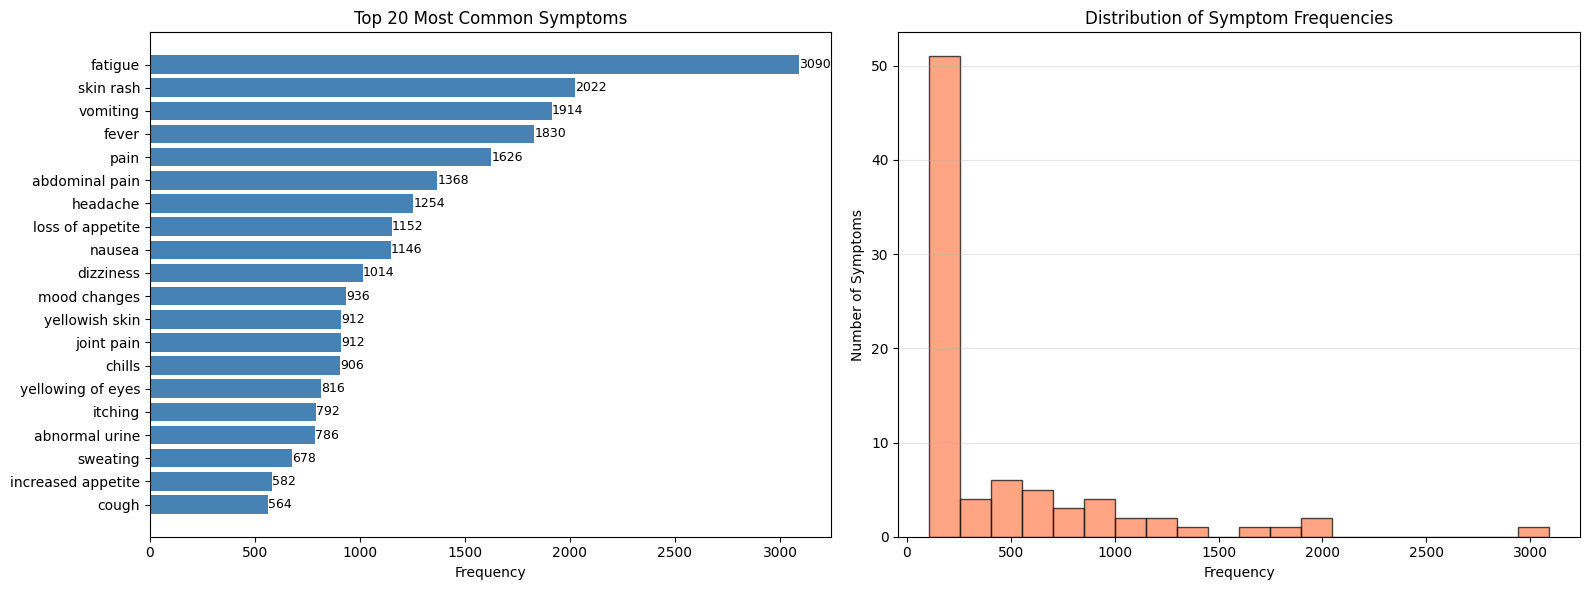


 STEP 5: Running Apriori Algorithm...

Parameters:
  Total transactions: 82
  Minimum support: 0.1 (10%)
  Minimum absolute count: 9 transactions
  Minimum confidence: 0.5 (50%)

Running Apriori Algorithm
Total transactions: 82
Minimum support: 0.1 (8 transactions)

Iteration k=1:
  Candidates: 83
  Frequent itemsets: 19

Iteration k=2:
  Candidates: 171
  Frequent itemsets: 34

Iteration k=3:
  Candidates: 39
  Frequent itemsets: 16

Iteration k=4:
  Candidates: 1
  Frequent itemsets: 1

Apriori Algorithm Completed!
Total frequent itemsets found: 70

 STEP 6: Visualizing Frequent Itemsets...


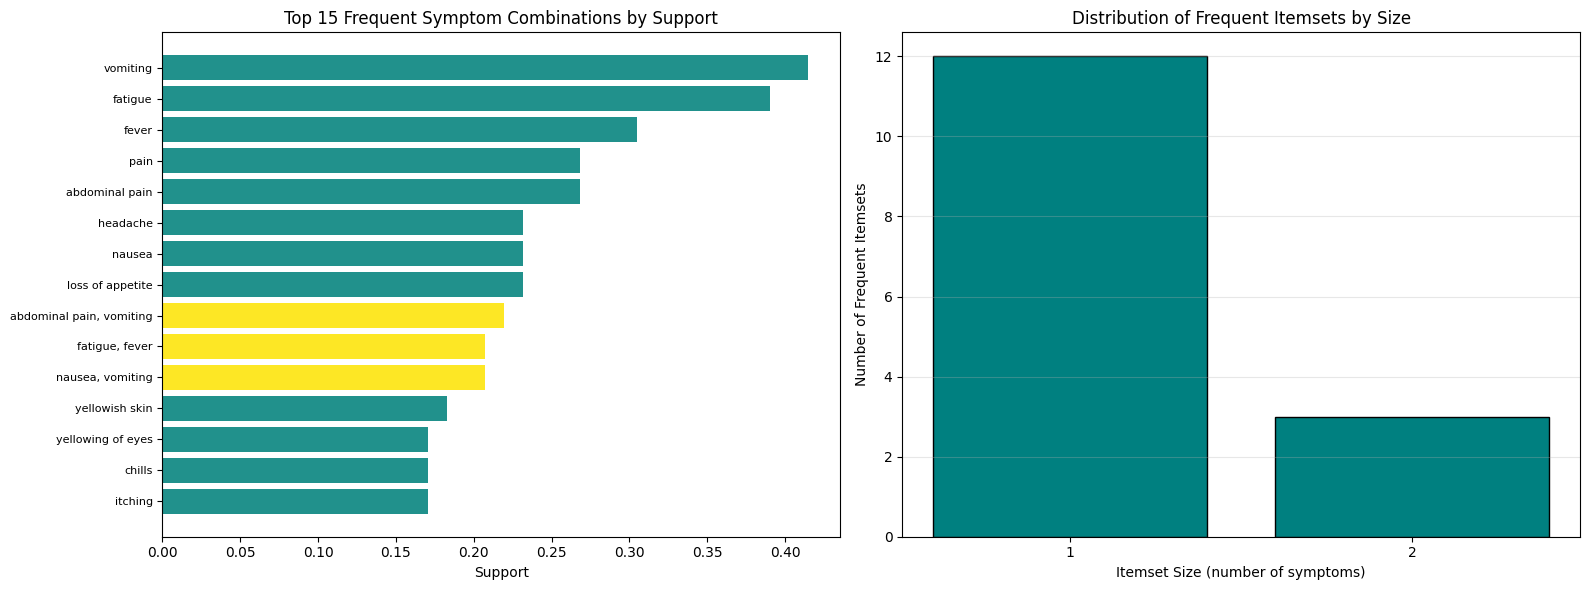

Saved: ./outputs/frequent_itemsets.png

 STEP 7: Generating Association Rules...

Generated 112 association rules
Minimum confidence threshold: 0.5
[{'antecedent': frozenset({'headache', 'nausea'}), 'consequent': frozenset({'vomiting'}), 'support': 0.10975609756097561, 'confidence': 1.0, 'lift': 2.4117647058823533}, {'antecedent': frozenset({'chills', 'fatigue'}), 'consequent': frozenset({'fever'}), 'support': 0.12195121951219512, 'confidence': 1.0, 'lift': 3.2800000000000002}, {'antecedent': frozenset({'loss of appetite', 'yellowish skin'}), 'consequent': frozenset({'yellowing of eyes'}), 'support': 0.13414634146341464, 'confidence': 1.0, 'lift': 5.857142857142857}, {'antecedent': frozenset({'yellowing of eyes', 'yellowish skin'}), 'consequent': frozenset({'loss of appetite'}), 'support': 0.13414634146341464, 'confidence': 1.0, 'lift': 4.315789473684211}, {'antecedent': frozenset({'yellowish skin', 'vomiting'}), 'consequent': frozenset({'abdominal pain'}), 'support': 0.134146341463414

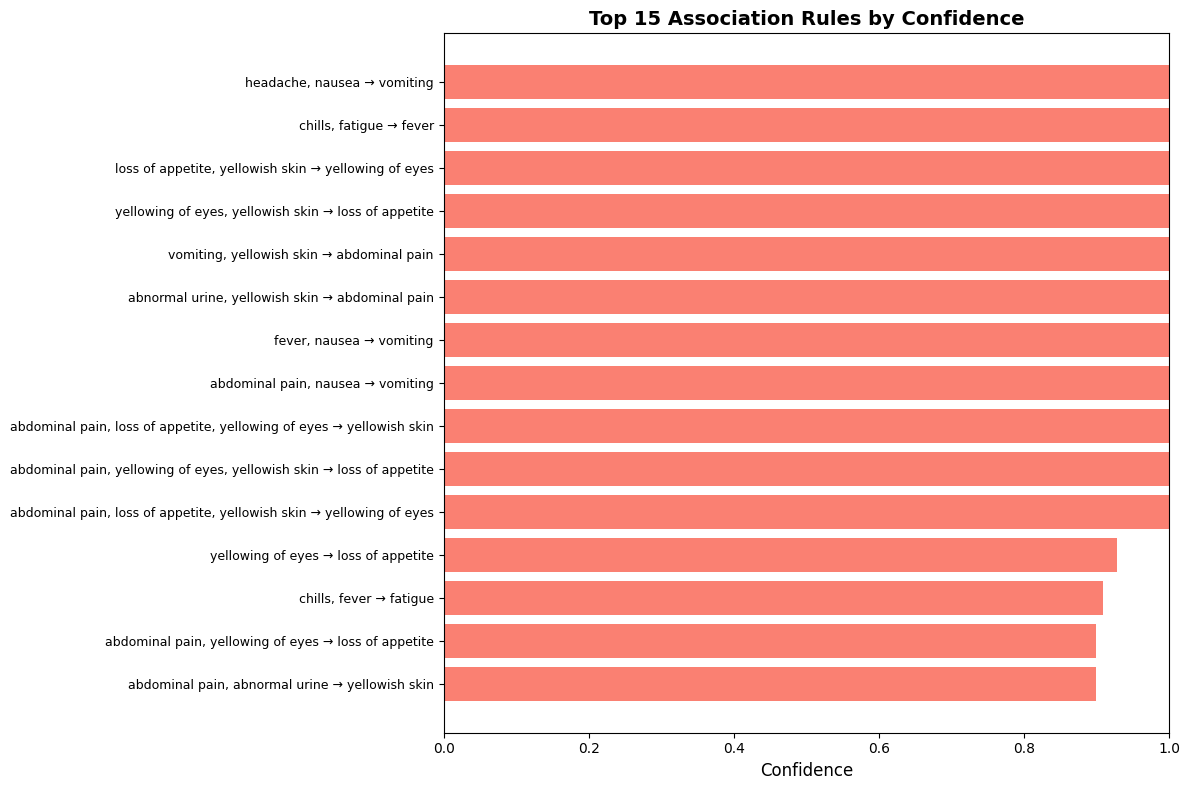

Saved: ./outputs/rules_by_confidence.png


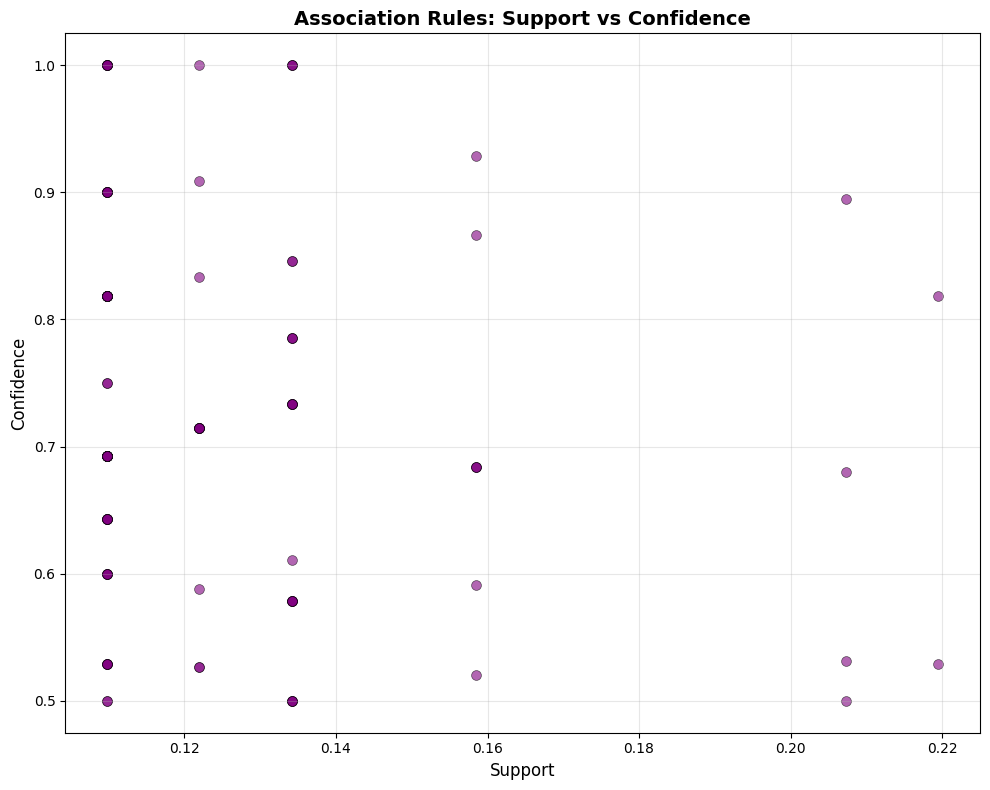

Saved: ./outputs/support_vs_confidence.png


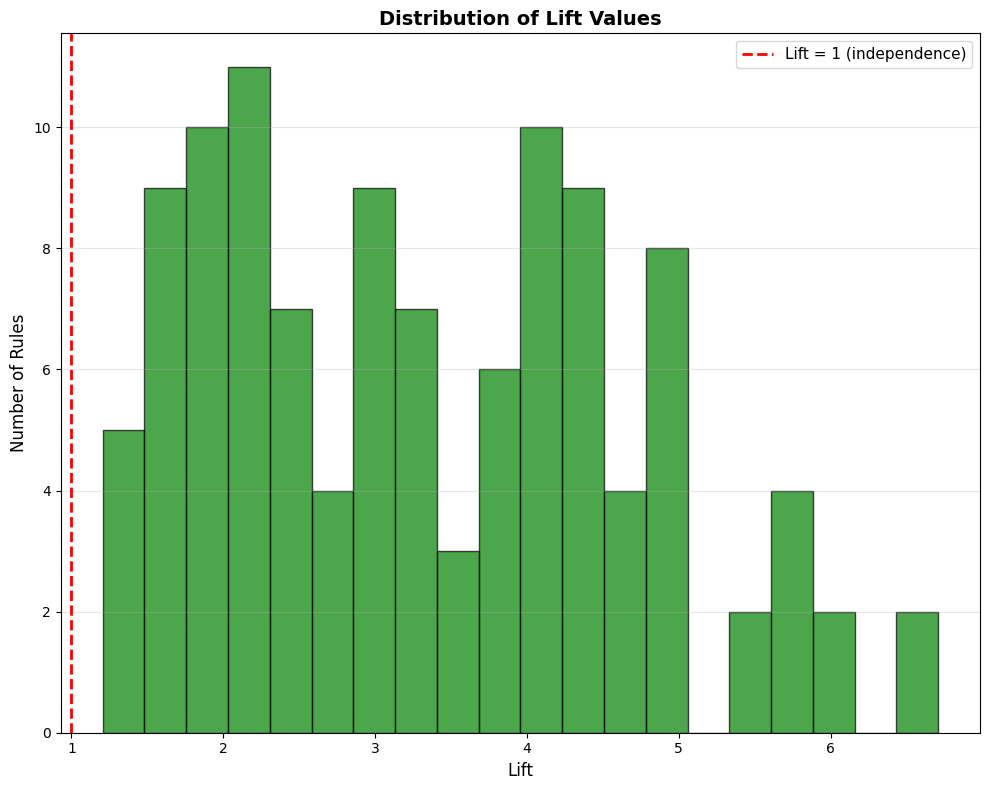

Saved: ./outputs/lift_distribution.png


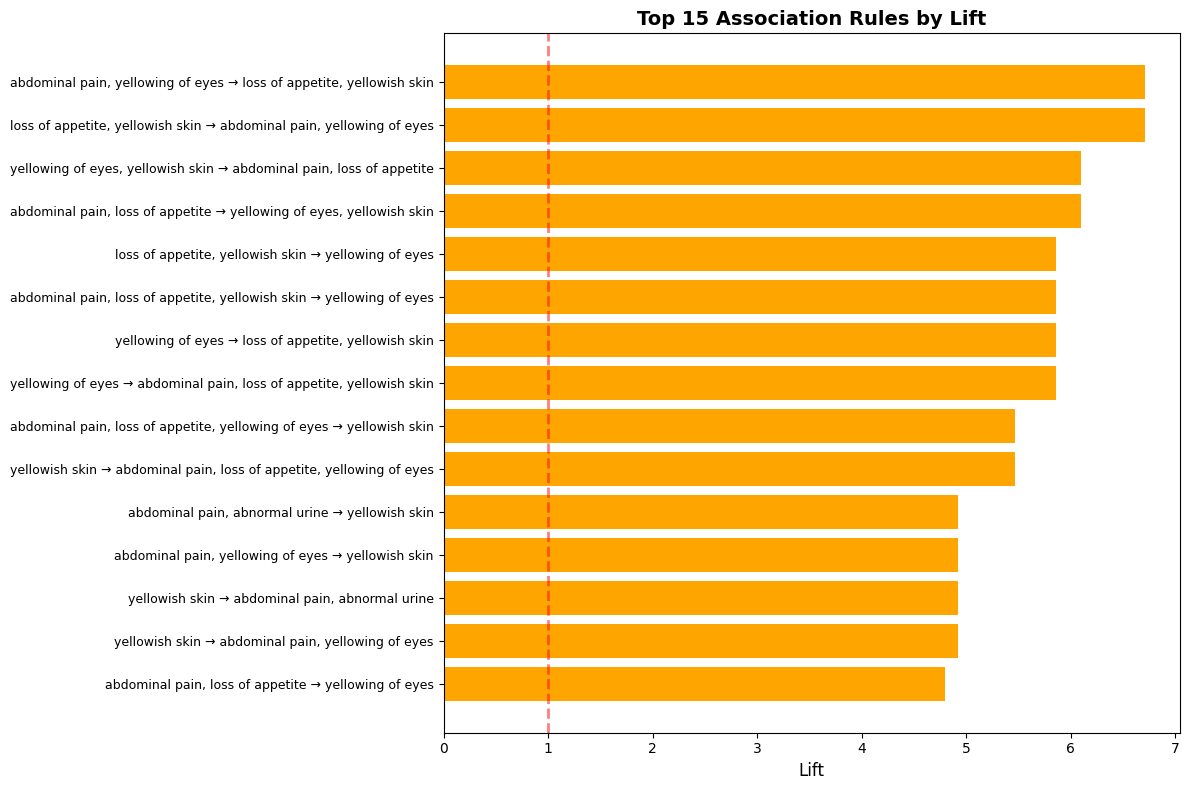

Saved: ./outputs/rules_by_lift.png

 All 4 plots saved successfully!

 STEP 9: Saving Results...

SUMMARY STATISTICS

 Frequent Itemsets:
  Total frequent itemsets: 70
  Size 1: 19 itemsets
  Size 2: 34 itemsets
  Size 3: 16 itemsets
  Size 4: 1 itemsets

 Association Rules:
  Total rules generated: 112
  Average confidence: 0.7276
  Average support: 0.1247
  Average lift: 3.3317

 Top 5 Rules by Confidence:
  1. headache, nausea → vomiting | Supp: 0.1098, Conf: 1.0000, Lift: 2.4118
  2. chills, fatigue → fever | Supp: 0.1220, Conf: 1.0000, Lift: 3.2800
  3. loss of appetite, yellowish skin → yellowing of eyes | Supp: 0.1341, Conf: 1.0000, Lift: 5.8571
  4. yellowing of eyes, yellowish skin → loss of appetite | Supp: 0.1341, Conf: 1.0000, Lift: 4.3158
  5. yellowish skin, vomiting → abdominal pain | Supp: 0.1341, Conf: 1.0000, Lift: 3.7273

Saved: ./outputs/frequent_itemsets.csv
Saved: ./outputs/association_rules.csv

DETAILED FREQUENT ITEMSETS INSPECTION

SIZE 1 ITEMSETS (19 total)

1

In [ ]:
def main():
    print("="*70)
    print("TASK 2.1: ANALYSIS OF SYMPTOM CO-OCCURRENCE PATTERNS")
    print("Using Apriori Algorithm")
    print("="*70)

    # STEP 1: LOAD DATA
    print("\n STEP 1: Loading Dataset...")
    filepath = 'data/disease_symptom/dataset.csv'
    df = load_disease_symptom_data(filepath)
    
    if df is None:
        print("\n Cannot proceed without dataset!")
        return
    
    print(f"\nDataset preview:")
    print(df.head())
    
    # STEP 2: PREPARE TRANSACTIONS
    print("\n STEP 2: Preparing Transactions...")
    transactions, disease_names, symptom_stats = prepare_transactions(
        df, 
        normalize_synonyms=True, 
        verbose=True
    )
        
    # STEP 3: DATA AUGMENTATION
    print("\n STEP 3: Augmenting Dataset...")
    transactions_aug, names_aug = augment_transactions(
        transactions, 
        disease_names, 
        noise_rate=0.05,
        verbose=True
    )
    
    # STEP 4: VISUALIZE SYMPTOM DISTRIBUTION
    print("\n STEP 4: Visualizing Symptom Distribution...")
    visualize_symptom_distribution(symptom_stats, top_n=20)
    
    # STEP 5: RUN APRIORI ALGORITHM
    print("\n STEP 5: Running Apriori Algorithm...")
    
    # Parameters
    MIN_SUPPORT = 0.10      
    MIN_CONFIDENCE = 0.5    
    
    min_count = int(np.ceil(len(transactions_aug) * MIN_SUPPORT))
    
    print(f"\nParameters:")
    print(f"  Total transactions: {len(transactions_aug)}")
    print(f"  Minimum support: {MIN_SUPPORT} ({MIN_SUPPORT*100:.0f}%)")
    print(f"  Minimum absolute count: {min_count} transactions")
    print(f"  Minimum confidence: {MIN_CONFIDENCE} ({MIN_CONFIDENCE*100:.0f}%)")
    print()
    
    # Initialize and run Apriori
    apriori = AprioriAlgorithm(
        min_support=MIN_SUPPORT, 
        min_confidence=MIN_CONFIDENCE
    )    
    frequent_itemsets = apriori.fit(transactions_aug, verbose=True)
    
    # STEP 6: VISUALIZE FREQUENT ITEMSETS
    print("\n STEP 6: Visualizing Frequent Itemsets...")
    visualize_frequent_itemsets(frequent_itemsets, top_n=15)
    
    # STEP 7: GENERATE ASSOCIATION RULES
    print("\n STEP 7: Generating Association Rules...")
    rules = apriori.generate_association_rules(
        min_confidence=MIN_CONFIDENCE, 
        verbose=True
    )
    print(rules)
    
    # STEP 8: VISUALIZE ASSOCIATION RULES
    if rules:
        print("\n STEP 8: Visualizing Association Rules...")
        visualize_association_rules(rules, top_n=15)
    else:
        print("\n No association rules found with current thresholds.")
        print("   Try lowering min_confidence or min_support.")
    
    # STEP 9: SAVE RESULTS
    print("\n STEP 9: Saving Results...")
    print_summary_statistics(frequent_itemsets, rules)
    save_results_to_csv(frequent_itemsets, rules)

    inspect_frequent_itemsets_detailed(frequent_itemsets, top_n=5)
    
    # ========================================================================
    # COMPLETION
    # ========================================================================
    print("\n" + "="*70)
    print("TASK 2.1 COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"\nGenerated files in '{OUTPUT_DIR}/' directory:")
    print("  1. symptom_distribution.png      - Top symptoms visualization")
    print("  2. frequent_itemsets.png          - Frequent patterns chart")
    print("  3. association_rules.png          - Rules visualization")
    print("  4. frequent_itemsets.csv          - Frequent itemsets data")
    print("  5. association_rules.csv          - Association rules data")
    print("\n" + "="*70)


if __name__ == "__main__":
    # Run main analysis
    main()